# Predição de uma onda senoidal


Objectivo: prever o próximo valor de uma onda senoidal com ruído.

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.preprocessing import MinMaxScaler

In [89]:
# Semente aleatória para reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

In [90]:
# ==============================================================
# PASSO 1: GERAR OS DADOS: onda senoidal + ruído
# ==============================================================

t = np.linspace(0, 100, 1000)           # 1000 pontos de tempo
sinal = np.sin(t) + 0.1 * np.random.randn(len(t))  # seno + pequeno ruído

print(f"Total de amostras: {sinal.shape}")

Total de amostras: (1000,)


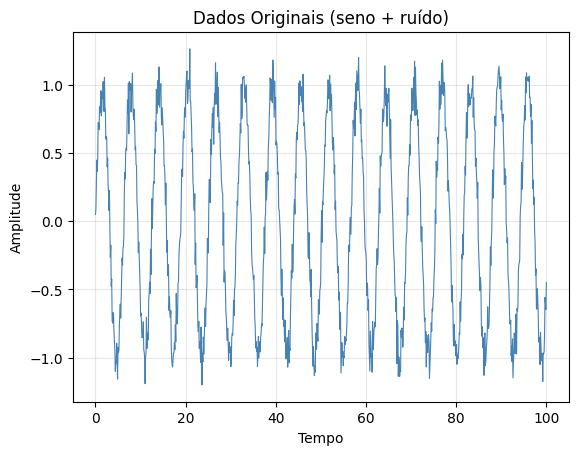

In [91]:
# --- Gráfico 1: Série temporal completa ---
plt.figure()
plt.plot(t, sinal, color='steelblue', linewidth=0.8)
plt.title("Dados Originais (seno + ruído)")
plt.xlabel("Tempo")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

In [92]:
# ==============================================================
# PASSO 2: PRÉ-PROCESSAMENTO: Normalizando e preparando janelas de tempo
# ==============================================================

# Divisão treino / teste (80% / 20%)
split = int(len(sinal) * 0.8)
sinal_treino, sinal_teste = sinal[:split], sinal[split:]

print(f"   sinal treino: {len(sinal_treino)} amostras")
print(f"   sinal teste:  {len(sinal_teste)} amostras\n")

# Normalizar para o intervalo [0, 1] — facilita o treinamento
scaler = MinMaxScaler(feature_range=(0, 1))
sinal_treino_norm = scaler.fit_transform(sinal_treino.reshape(-1, 1))
sinal_teste_norm = scaler.transform(sinal_teste.reshape(-1, 1))

# Criar janelas de tempo (lookback = quantos passos o modelo "olha" para trás)
LOOKBACK = 30   # a LSTM vai usar os últimos 30 pontos para prever o próximo

def criar_janelas(dados, lookback):
    """
    Transforma a série temporal em pares (X, y) onde:
      X = janela de 'lookback' pontos anteriores
      y = próximo ponto a prever
    """
    X, y = [], []
    for i in range(len(dados) - lookback):
        X.append(dados[i : i + lookback])
        y.append(dados[i + lookback])
    return np.array(X), np.array(y)

X_treino, y_treino = criar_janelas(sinal_treino_norm, LOOKBACK)
print(f"   Janelas de treino criadas: {X_treino.shape[0]}")
print(f"   Forma de X_treino: {X_treino.shape}  → (amostras, timesteps, features)")
print(f"   Forma de y_treino: {y_treino.shape}  → (amostras, 1)\n")

X_teste, y_teste = criar_janelas(sinal_teste_norm, LOOKBACK)
print(f"   Janelas de teste criadas: {X_teste.shape[0]}")
print(f"   Forma de X_teste: {X_teste.shape}  → (amostras, timesteps, features)")
print(f"   Forma de y_teste: {y_teste.shape}  → (amostras, 1)\n")

   sinal treino: 800 amostras
   sinal teste:  200 amostras

   Janelas de treino criadas: 770
   Forma de X_treino: (770, 30, 1)  → (amostras, timesteps, features)
   Forma de y_treino: (770, 1)  → (amostras, 1)

   Janelas de teste criadas: 170
   Forma de X_teste: (170, 30, 1)  → (amostras, timesteps, features)
   Forma de y_teste: (170, 1)  → (amostras, 1)



In [93]:
# ==============================================================
# PASSO 3: CONSTRUIR O MODELO LSTM
# ==============================================================

modelo = Sequential([
    # shape = (timesteps, features) = (30, 1)
    Input(shape=(LOOKBACK, 1)),

    # Camada LSTM com 64 unidades
    LSTM(64),

    # Camada de saída: 1 neurônio → prevê o próximo valor
    Dense(1)
])

modelo.compile(
    optimizer='adam',
    loss='mean_squared_error'   # MSE é padrão para regressão
)

modelo.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
# ==============================================================
# PASSO 4: TREINAR O MODELO
# ==============================================================
historico = modelo.fit(
    X_treino, y_treino,
    epochs=40,
    batch_size=32,
    validation_split=0.1,   # 10% do treino para validação interna
)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0529 - val_loss: 0.0233
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0155 - val_loss: 0.0065
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0037 - val_loss: 0.0020
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 9/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 10/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 11/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 12/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


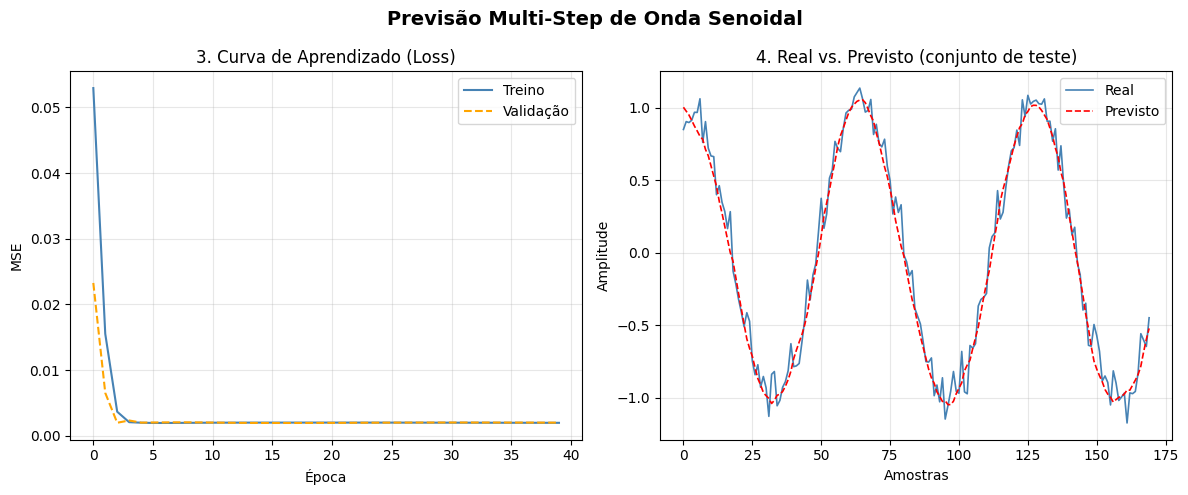

In [95]:
# ==============================================================
# PASSO 5: AVALIAR E VISUALIZAR OS RESULTADOS
# ==============================================================

# Previsões
y_pred_norm = modelo.predict(X_teste)

# Desnormalizar para a escala original
y_pred = scaler.inverse_transform(y_pred_norm)
y_real = scaler.inverse_transform(y_teste)

# ==== GRÁFICOS ====
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Previsão Multi-Step de Onda Senoidal", fontsize=14, fontweight='bold')

# --- Gráfico 3: Perda durante o treinamento ---
axs[0].plot(historico.history['loss'],     label='Treino',    color='steelblue')
axs[0].plot(historico.history['val_loss'], label='Validação', color='orange', linestyle='--')
axs[0].set_title("3. Curva de Aprendizado (Loss)")
axs[0].set_xlabel("Época")
axs[0].set_ylabel("MSE")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# --- Gráfico 4: Real vs. Previsto ---
axs[1].plot(y_real[:200],  label='Real',    color='steelblue', linewidth=1.2)
axs[1].plot(y_pred[:200],  label='Previsto', color='red', linewidth=1.2, linestyle='--')
axs[1].set_title("4. Real vs. Previsto (conjunto de teste)")
axs[1].set_xlabel("Amostras")
axs[1].set_ylabel("Amplitude")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()